
0: 480x640 1 bicycle, 1 car, 1 truck, 1 dog, 173.5ms
Speed: 4.2ms preprocess, 173.5ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Time took: 0.22s
tensor([[1.3111e+02, 2.1989e+02, 3.0925e+02, 5.4184e+02, 9.0800e-01, 1.6000e+01],
        [1.3063e+02, 1.3961e+02, 5.6827e+02, 4.2085e+02, 8.8876e-01, 1.0000e+00],
        [4.6749e+02, 7.4809e+01, 6.9209e+02, 1.7167e+02, 5.3058e-01, 2.0000e+00],
        [4.6716e+02, 7.4549e+01, 6.9261e+02, 1.7178e+02, 5.0862e-01, 7.0000e+00]])


array([[[ 50,  58,  57],
        [ 51,  59,  58],
        [ 53,  61,  60],
        ...,
        [ 47,  89, 142],
        [ 41,  50,  88],
        [ 47,  71,  63]],

       [[ 51,  59,  58],
        [ 51,  59,  58],
        [ 52,  60,  59],
        ...,
        [ 37,  74, 124],
        [ 41,  50,  84],
        [ 46,  70,  58]],

       [[ 51,  59,  58],
        [ 51,  59,  58],
        [ 52,  60,  59],
        ...,
        [ 25,  54,  98],
        [ 48,  54,  77],
        [ 43,  62,  45]],

       ...,

       [[179, 168, 160],
        [179, 168, 160],
        [182, 171, 163],
        ...,
        [ 64,  64,  80],
        [ 36,  39,  53],
        [ 48,  53,  62]],

       [[180, 169, 161],
        [179, 168, 160],
        [175, 164, 156],
        ...,
        [ 61,  61,  79],
        [ 37,  40,  54],
        [ 52,  56,  67]],

       [[176, 165, 157],
        [178, 167, 159],
        [172, 161, 153],
        ...,
        [ 62,  62,  80],
        [ 33,  36,  50],
        [ 35,  39,  50]]], dtype=uint8)
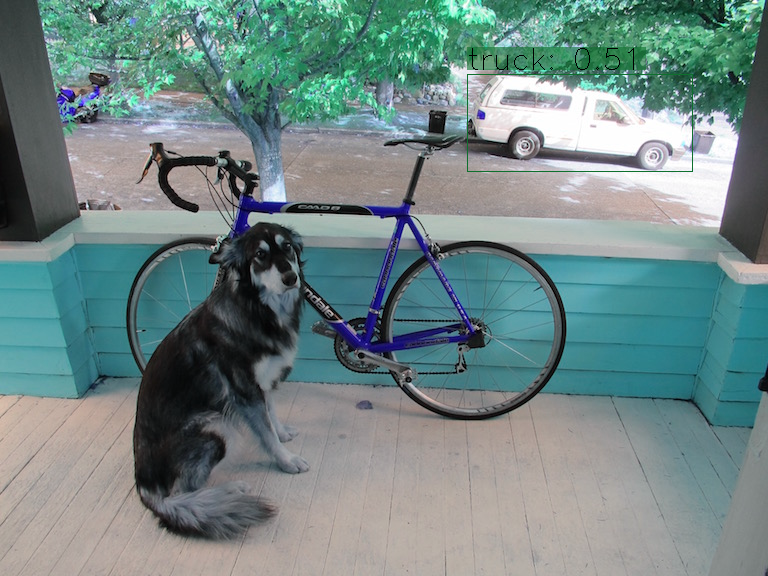

In [9]:
!pip install ultralytics
import numpy as np

import os
import cv2
import time
from ultralytics import YOLO
CONFIDENCE = 0.5
font_scale = 1
thickness = 1
model = YOLO("yolov8n.pt")
!wget -q https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names -O /content/coco.names
labels = open("/content/coco.names").read().strip().split("\n")
!wget -q https://raw.githubusercontent.com/pjreddie/darknet/master/data/dog.jpg -O /content/dog.jpg
colors = np.random.randint(0, 255, size=(len(labels), 3), dtype="uint8")
path_name = "/content/dog.jpg"
image = cv2.imread(path_name)
file_name = os.path.basename(path_name)
filename, ext = file_name.split(".")
start = time.perf_counter()
results = model.predict(image, conf=CONFIDENCE)[0]
time_took = time.perf_counter() - start
print(f"Time took: {time_took:.2f}s")
print(results.boxes.data)
for data in results.boxes.data.tolist():


  xmin, ymin, xmax, ymax, confidence, class_id = data
  xmin = int(xmin)
  ymin = int(ymin)
  xmax = int(xmax)
  ymax = int(ymax)
  class_id = int(class_id)


color = [int(c) for c in colors[class_id]]

cv2.rectangle(image, (xmin, ymin), (xmax, ymax), color=color, thickness=thickness)
text = f"{labels[class_id]}: {confidence:.2f}"

# calculate text width & height to draw the transparent boxes as background of the text
(text_width, text_height) = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, fontScale=font_scale, thickness=thickness)[0]
text_offset_x = xmin
text_offset_y = ymin - 5
box_coords = ((text_offset_x, text_offset_y), (text_offset_x + text_width + 2, text_offset_y - text_height))

overlay = image.copy()
cv2.rectangle(overlay, box_coords[0], box_coords[1], color=color, thickness=cv2.FILLED) # add opacity (transparency to the box)
image = cv2.addWeighted(overlay, 0.6, image, 0.4, 0) # now put the text (label: confidence %)
cv2.putText(image, text, (xmin, ymin - 5), cv2.FONT_HERSHEY_SIMPLEX, fontScale=font_scale, color=(0, 0, 0), thickness=thickness)